In [1]:
# !pip install -U pip wheel
# !pip install -q -r /Users/ryan/github/lltk/requirements.txt
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'/Users/ryan/github/prosodic')
sys.path.insert(0,'/Users/ryan/github/lltk')
sys.path.insert(0,'/Users/ryan/github/logmap')
from llmdh import *
import prosodic
from prosodic import Word
prosodic.USE_CACHE=False
import plotnine as p9
p9.options.figure_size=11,8
pd.options.display.max_rows=200

In [2]:
def get_df_poems():
    df_poems = pd.read_pickle('data.allpoems.pkl').fillna('')
    
    excl_prompts=[
        'Write an unryhmed poem in the style of Shakespeare\'s dramatic monologues.',
        'Write a poem in the style of Shakespeare\'s dramatic monologues.',
        'Write a poem in the style of e.e. cummings',
        # 'Write a poem in the style of Walt Whitman.',
        'Write a poem in the style of Wallace Stevens.',
        'Continue the following poem:\n\nTyping, typing, fingers on the keyboard\nThe keys crack and bend under sweat and weight,\n'
    ]

    incl_prompts = [
        '',
        # 'Write a poem (with 20+ lines).',
        # 'Write a long poem.',
        # 'Write a poem in the style of Walt Whitman.',
        # 'Write a long poem that does rhyme.',
        # 'Write a poem (with 20+ lines) that does NOT rhyme.',
        # 'Write a poem (with 20+ lines) that rhymes.',
        # 'Write a long poem that does NOT rhyme.',
        'Write a poem.',
        'Write a poem that does rhyme.',
        'Write a poem that does NOT rhyme.',

        # 'Write a poem in ballad stanzas.',
        # 'Write a poem in heroic couplets.',
        # 'Write a poem in free verse.',
        # 'Write a poem in groups of two lines.',
        # 'Write a poem in blank verse.',
        # 'Write a poem in stanzas of 4 lines each.',
        # 'Write an unrhymed poem.',
        # 'Write an rhyming poem.',
        # 'Write a poem in the style of Emily Dickinson.',
        # "Write an ryhmed poem in the style of Shakespeare's sonnets.",
        # 'Write a short poem that does NOT rhyme.',
        # 'Write a short poem.',
        # 'Write a short poem that does rhyme.'
    ]

    df_poems = df_poems[~df_poems.prompt.isin(excl_prompts)]
    # df_poems = df_poems[df_poems.prompt.isin(incl_prompts)]
    return df_poems

In [3]:
get_df_poems().prompt.value_counts()

prompt
                                                               59688
Write a long poem.                                               425
Write a poem (with 20+ lines).                                   396
Write a poem.                                                    390
Write a poem in groups of two lines.                             383
Write a poem (with 20+ lines) that does NOT rhyme.               382
Write a poem in heroic couplets.                                 376
Write a poem (with 20+ lines) that rhymes.                       372
Write a long poem that does rhyme.                               370
Write a poem in the style of Emily Dickinson.                    369
Write a poem that does rhyme.                                    369
Write a long poem that does NOT rhyme.                           365
Write a poem in the style of Walt Whitman.                       350
Write a poem in ballad stanzas.                                  348
Write a poem in stanzas of 

In [4]:
def get_allpoems_with_rhyme_data(min_lines=10):
    df_poems = get_df_poems()
    odf=pd.read_csv('data.allpoems.rhyme_data3.tsv', sep='\t')
    odf['poem_hash'] = odf['poem']
    df_poems['poem_hash'] = df_poems['poem'].apply(hashstr)
    df2 = odf[['num_rhyming_lines','poem_hash', 'num_lines']].merge(df_poems, on='poem_hash', how='inner', suffixes=['', '_1'])
    df2['num_rhyming_lines'] = pd.to_numeric(df2['num_rhyming_lines'], errors='coerce')
    df2['num_lines'] = pd.to_numeric(df2['num_lines'], errors='coerce')
    df2['perc_rhyming_lines'] = df2['num_rhyming_lines'] / df2['num_lines']
    df2['poem_rhymes'] = (df2['num_rhyming_lines'] > 0).apply(int)
    df2 = df2[df2.num_lines>=min_lines]
    return df2

df2 = get_allpoems_with_rhyme_data()
df2[['model','prompt','poem','num_lines','num_lines_1','num_rhyming_lines', 'num_rhyming_lines_1', 'poem_rhymes']]

,model,prompt,poem,num_lines,num_lines_1,num_rhyming_lines,num_rhyming_lines_1,poem_rhymes
0,claude-3-opus-20240229,Write a poem in blank verse.,"In solitude, I wander through the night,\nBene...",21,21,2,4,1
1,gpt-3.5-turbo,Write an ryhmed poem in the style of Shakespea...,"Upon the blooming roses' sweetest scent,\nI fi...",14,14,14,4,1
2,gpt-3.5-turbo,Write a poem (with 20+ lines) that rhymes.,"In fields of gold and oceans blue,\nWhere skie...",28,28,16,5,1
3,gpt-3.5-turbo,Write a short poem that does rhyme.,"In the stillness of the night,\nStars twinkle ...",12,12,10,4,1
4,gpt-3.5-turbo,Write a poem that does rhyme.,"In the quiet of the night,\nI sit and ponder ‘...",16,16,10,4,1
...,...,...,...,...,...,...,...,...
23248,b. 1750-1800,,"The eye was closed, and calm the breast;\n'TO ...",30,30,22,14,1
23249,b. 1850-1900,,I thought of a house where the stones seemed s...,19,19,0,4,0
23250,b. 1650-1700,,The Smart of my passed Follies now I feel;\n'T...,412,100,222,19,1
23251,b. 1650-1700,,"If to observe Religion's strictest Laws,\nMeri...",12,12,8,10,1


In [5]:
# df2.groupby(['model','prompt_type']).perc_rhyming_lines.mean().sort_values()

In [6]:
# df2.groupby('prompt').perc_rhyming_lines.mean().sort_values()

In [7]:
# df2.groupby(['model','prompt_type']).poem_rhymes.mean().sort_values()

In [8]:
# df3 = pd.concat(gdf for g,gdf in df2.groupby(['model','prompt']) if len(gdf)>=20)
# df3.groupby(['model','prompt_type']).mean(numeric_only=True).sort_values('poem_rhymes')

In [9]:
# df4 = df2.groupby(['model','prompt_type']).sum(numeric_only=True)
# df4['perc_rhyming_lines'] = df4['num_rhyming_lines'] / df4['num_lines']
# df4.perc_rhyming_lines.sort_values()

In [10]:
def get_figdf(min_lines=10):
    figdf = get_allpoems_with_rhyme_data(min_lines=min_lines)
    # figdf['fline']=figdf['poem'].apply(lambda x: x.strip().split('\n')[0])
    # figdf=figdf.drop_duplicates('fline')
    # len(df2), len(figdf)

    model_rename={'Chadwyck': 'Human',
    'claude-3-haiku-20240307': 'Claude (Anthropic)',
    'claude-3-opus-20240229': 'Claude (Anthropic)',
    'claude-3-sonnet-20240229': 'Claude (Anthropic)',
    'gemini-pro': 'Gemini (Google)',
    'gpt-3.5-turbo': 'GPT (OpenAI)',
    'gpt-4-turbo': 'GPT (OpenAI)',
    'llama2-uncensored:7b': 'Llama (open source)'}
    figdf['model']=figdf.model.apply(lambda x: model_rename.get(x,x))

    for k in ['model','prompt']:
        figdf[k] = pd.Categorical(
            figdf[k], 
            # categories=figdf.groupby(k).perc_rhyming_lines.median().sort_values(ascending=True).index,
            categories = sorted(figdf[k].unique(), reverse=True)
        )

    prompt_type_rename = {
        'MAYBE_rhyme':'LLM: Write a poem', 
        'DO_rhyme':'LLM: Write a rhyming poem', 
        'do_NOT_rhyme':'LLM: Write an unrhyming poem', 
        'Human':'Human: Poetic history'
    }

    figdf['prompt_type']=pd.Categorical(figdf['prompt_type'], categories=['Human','MAYBE_rhyme','DO_rhyme','do_NOT_rhyme'])
    figdf['prompt_type']=figdf.prompt_type.apply(lambda x: prompt_type_rename.get(x,x))
    # return figdf.prompt_type.value_counts()
    # figdf.to_pickle('data.figdf.allpoems.pkl')
    return figdf

get_figdf()

,num_rhyming_lines,poem_hash,num_lines,model,temp,prompt,poem,num_lines_1,num_rhyming_lines_1,perc_rhyming_lines,prompt_type,_id,_corpus,Unnamed: 0,a1,attautid,attbytes,attdbase,attgenre,attidref,attperi,attpoet,attpubn1,attpubn2,attrhyme,attsize,author,author_dob,author_dod,author_gender,collection,corpus,hi,idref,idz,l,mainhead,pbl,posthumous,sombiog,t1,t2,t3,title,ty,volhead,y1,year,attpubl,bytes,note,publish,poemcopy,lb,caption,preface,signed,subhead,dedicat,year_new,year_old,sompoet,reflink,attauth,somauth,conclude,epigraph,aliasinv,gap,trailer,alias,speaker,break,item,lacuna,p,pb,caesura,firstl,epilogue,argument,attgend,attnatn,stage,greek,label,figure,hideinft,u,chid,it,sup,audio,sl,anote,xref,prologue,sub,cell,target,bo,bnote,video,pndfig,ybin,path_txt,poem_rhymes
0,2,977e569777bb,21,Claude (Anthropic),0.782946,Write a poem in blank verse.,"In solitude, I wander through the night,\nBene...",21,4,0.095238,LLM: Write an unrhyming poem,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1
1,14,4bdcffbdbb68,14,GPT (OpenAI),0.8751,Write an ryhmed poem in the style of Shakespea...,"Upon the blooming roses' sweetest scent,\nI fi...",14,4,1.000000,LLM: Write a rhyming poem,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1
2,16,2c0ffa809a58,28,GPT (OpenAI),1.341424,Write a poem (with 20+ lines) that rhymes.,"In fields of gold and oceans blue,\nWhere skie...",28,5,0.571429,LLM: Write a rhyming poem,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1
3,10,bf171c212411,12,GPT (OpenAI),0.269613,Write a short poem that does rhyme.,"In the stillness of the night,\nStars twinkle ...",12,4,0.833333,LLM: Write a rhyming poem,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1
4,10,4bdbec34f589,16,GPT (OpenAI),1.306489,Write a poem that does rhyme.,"In the quiet of the night,\nI sit and ponder ‘...",16,4,0.625000,LLM: Write a rhyming poem,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23248,22,9011dfc50e2c,30,b. 1750-1800,,,"The eye was closed, and calm the breast;\n'TO ...",30,14,0.733333,Human: Poetic history,_chadwyck_poetry/american/am0780/Z300172942,chadwyck_poetry,204080.0,"Gould, Hannah Flagg, 1789-1865",907.0,2Kb,American Poetry,,A3022553,Mid Nineteenth-Century 1835-1869,"Gould, Hannah Flagg, 1789-1865",1839.0,1839.0,y,2Kb,"Gould, Hannah Flagg, 1789-1865",1789.0,1865.0,female,1 2,ChadwyckPoetry,The,Z300172942,Z300172942,'T was Sleep—the weary was at rest!,THE THRICE&hyphen;CLOSED EYE.,"Phillips, Sampson and Company",False,907.0,THE THRICE&hyphen;CLOSED EYE.,Poems (1839),Literature Online,THE THRICE&hyphen;CLOSED EYE.,DATA,Poems (1839),1851,1819.0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,b. 1700-1800,/Users/ryan/lltk_data/corpora/chadwyck_poetry/...,1
23249,0,4055c84ae259,19,b. 1850-1900,,,I thought of a house where the stones seemed s...,19,4,0.000000,Human: Poetic history,_chadwyck_poetry/modern/car2501/Z300551542,chadwyck_poetry,181963.0,"MacDiarmid, Hugh, 1892-1978",1368.0,2Kb,Modern Poetry,,X3002827,Twentieth-Century 1900-1999,"MacDiarmid, Hugh, 1892-1978",1993.0,1993.0,,2Kb,"MacDiarmid, Hugh, 1892-1978",1892.0,1978.0,male,1 2,ChadwyckPoetry,I thought,Z300551542,Z300551542,"And became instinct with hope, hope as solid a...",Lo! A Child is Born,Carcanet,True,1368.0,Lo! A Child is Born,Complete Poems: Volume I (1993): SECOND HYMN T...,Literature Online,Lo! A Child

In [11]:
def plot_fig(min_lines=10, value='perc_rhyming_lines'):
    figdf = get_figdf(min_lines=min_lines)
    figdf[value]*=100
    figdf[f'{value}_bin'] = figdf[value].apply(lambda x: int(round(x,0)))
    figdf2=pd.concat(
        gdf.iloc[:1].assign(poem_count=len(gdf))
        for g,gdf in figdf.groupby(['prompt_type','model',f'{value}_bin'])
    )

    fig=p9.ggplot(figdf, p9.aes(x='model', y=value))
    fig+=p9.theme_classic()
    fig+=p9.theme(axis_text_x=p9.element_text(angle=90))
    fig+=p9.geom_point(p9.aes(size='poem_count'), shape='x', data=figdf2, alpha=.9)
    fig+=p9.geom_boxplot(alpha=.8, outlier_shape='')
    fig+=p9.facet_wrap('prompt_type', nrow=9, scales='free_y')
    fig+=p9.labs(
        title="Formal Stuckness in AI: even when told not to rhyme, most LLM-generated poems rhyme anyway",
        y='Percent of lines rhyming',
        x='Type of LLM model',
        size='Number of poems',
        caption=''
    )

    # Add a horizontal line for the overall median
    latest_median = figdf[figdf.model=='b. 1950-2000'][value].median()
    fig += p9.geom_hline(yintercept=latest_median, linetype='dashed', color='red')

    anndata = figdf[(figdf.model == 'b. 1950-2000') & (figdf.prompt_type.str.contains('Human'))].sample(frac=1)
    anndata[value] = anndata[value].median()
    anndata=anndata.iloc[:1]

    fig+=p9.geom_text(data=anndata, label='Median for contemporary verse', ha='left', va='bottom', size=8, color='red', nudge_y=1, nudge_x=-1.1)

    fig+=p9.coord_flip()
    fig.save(f'fig.rhyme_box_plots.{value}.png')
    return fig

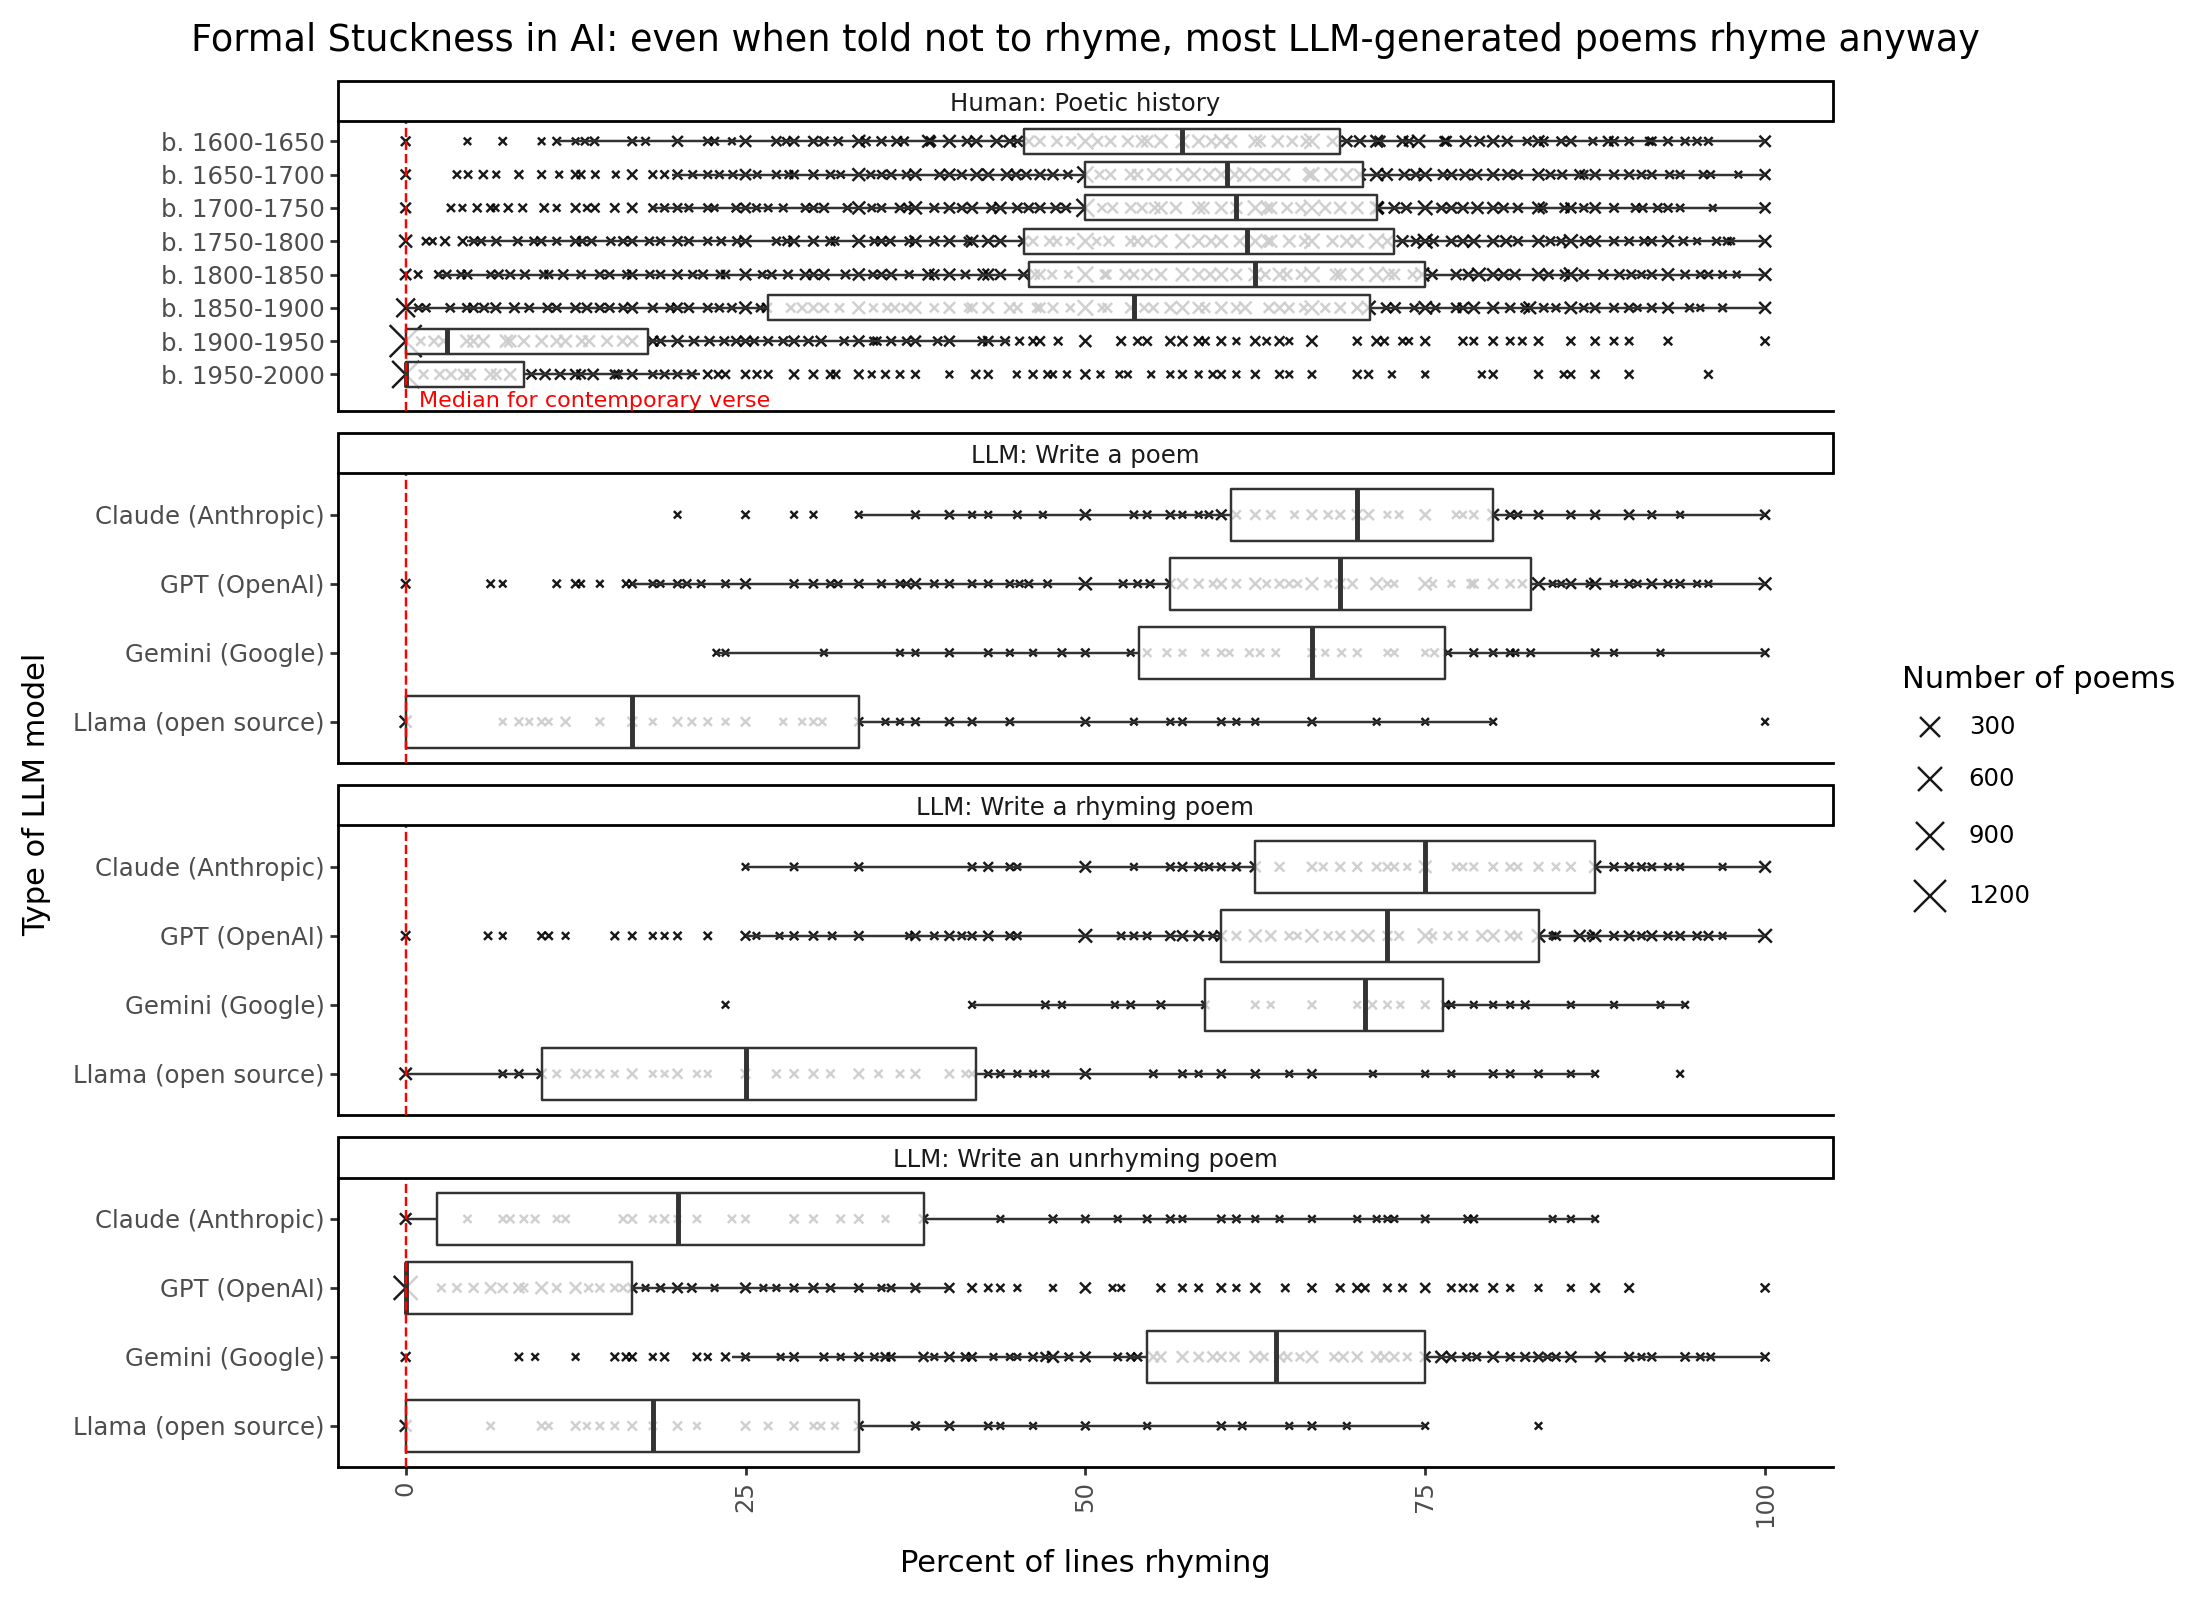

In [12]:
plot_fig(min_lines=10)

In [133]:
# plot_fig(min_lines=10, value='poem_rhymes')

In [172]:
# fig=p9.ggplot(figdf, p9.aes(x='prompt_type', y='perc_rhyming_lines'))
# fig+=p9.theme_classic()
# fig+=p9.theme(axis_text_x=p9.element_text(angle=90))
# # fig+=p9.geom_violin(alpha=.75)
# fig+=p9.geom_point(p9.aes(size='poem_count'), shape='x', data=figdf2, alpha=.9)
# fig+=p9.geom_boxplot(p9.aes(color='prompt_type'), alpha=.8, outlier_shape='')
# # fig+=p9.geom_smooth()
# # fig+=p9.facet_grid('model~prompt')
# # fig+=p9.facet_wrap('model', ncol=7)
# # fig+=p9.facet_wrap('prompt_type', ncol=3)
# # fig+=p9.facet_wrap('prompt_type', ncol=3)
# # fig+=p9.facet_grid('model~prompt_type')
# # figdf['prompt_type']=pd.Categorical()
# fig+=p9.labs(
#     title="Formal Stuckness in AI: even when told not to rhyme, most LLM-generated poems rhyme anyway",
#     y='Percent of lines rhyming',
#     x='LLM temperature parameter',
#     size='Number of lines',
#     # caption='Prompts used, in order of least to most rhymes:\n- '+'\n- '.join(figdf.prompt.unique())
# )
# fig+=p9.coord_flip()
# # fig.save('fig.rhyme_box_plots.3way.png')
# fig

In [ ]:

fig=p9.ggplot(figdf, p9.aes(x='prompt', y='perc_rhyming_lines', size='num_lines'))
fig+=p9.theme_classic()
fig+=p9.geom_boxplot(p9.aes(color='model'), alpha=.5, outlier_shape='')
fig+=p9.geom_boxplot(alpha=.25, outlier_shape='')
# fig+=p9.geom_point(shape='x')
# fig+=p9.facet_grid('model~prompt')
# fig+=p9.facet_wrap('model')
fig+=p9.coord_flip()
fig+=p9.labs(
    title='Formal Stuckness: varying the prompt to produce unrhymed verse produces no significant effect on rhyming',
    x='Percent of lines rhyming',
    y='Prompt to LLM',
    color='LLM model'
)
fig